# Introduction

In the last lesson, we saw that a convolutional classifier has two parts: a convolutional **base** and a **head** of dense layers. We learned that the job of the base is to extract visual features from an image, which the head would then use to classify the image.

Over the next few lessons, we're going to learn about the two most important types of layers that you'll usually find in the base of a convolutional image classifier. These are the **convolutional layer** with **ReLU activation**, and the **maximum pooling layer**. In Lesson 5, you'll learn how to design your own convnet by composing these layers into blocks that perform the feature extraction.

This lesson is about the convolutional layer with its ReLU activation function.

---

# Feature Extraction

Before we get into the details of convolution, let's discuss the *purpose* of these layers in the network. We're going to see how these three operations (convolution, ReLU, and maximum pooling) are used to implement the feature extraction process.

The **feature extraction** performed by the base consists of **three basic operations**:

1. **Filter** an image for a particular feature (convolution)
2. **Detect** that feature within the filtered image (ReLU)
3. **Condense** the image to enhance the features (maximum pooling)

The next figure illustrates this process. You can see how these three operations are able to isolate some particular characteristic of the original image (in this case, horizontal lines).

```mermaid
flowchart LR
    A[Original Image] --> B[Convolution\nFilter for horizontal lines]
    B --> C[ReLU\nKeep strong activations]
    C --> D[Max Pooling\nCondense and enhance]
    D --> E[Extracted Feature Map\nHorizontal lines emphasized]
```

---

# Weights

The weights a convnet learns during training are primarily contained in its **convolutional layers**. These weights we call **kernels**. We can represent them as small arrays:

> 🔲 A **3×3 kernel** — a small grid of learnable weights.

A kernel operates by **scanning over an image** and producing a **weighted sum** of pixel values. In this way, a kernel will act sort of like a polarized lens, emphasizing or deemphasizing certain patterns of information.

Kernels define how a convolutional layer is **connected to the layer that follows**. The kernel above will connect each neuron in the output to **nine neurons** in the input. By setting the dimensions of the kernels with `kernel_size`, you are telling the convnet how to form these connections. Most often, a kernel will have **odd-numbered dimensions** — like `kernel_size=(3, 3)` or `(5, 5)` — so that a single pixel sits at the center, but this is not a requirement.

The kernels in a convolutional layer determine what kinds of **features** it creates. During training, a convnet tries to learn what features it needs to solve the classification problem. This means finding the best values for its kernels.

---

# Activations

The activations in the network we call **feature maps**. They are what result when we apply a filter to an image; they contain the visual features the kernel extracts.

> 💡 From the pattern of numbers in the kernel, you can tell the kinds of feature maps it creates. Generally, what a convolution **accentuates** in its inputs will match the **shape of the positive numbers** in the kernel. For example, kernels with horizontal patterns of positive numbers will filter for **horizontal shapes**.

With the **`filters`** parameter, you tell the convolutional layer how many feature maps you want it to create as output.


In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters = 64, kernel_size = 3 , activation = 'relu'),
])


---

# Example — Apply Convolution and ReLU

We'll do the extraction ourselves in this example to understand better what convolutional networks are doing **"behind the scenes"**.

Here is the image we'll use for this example:


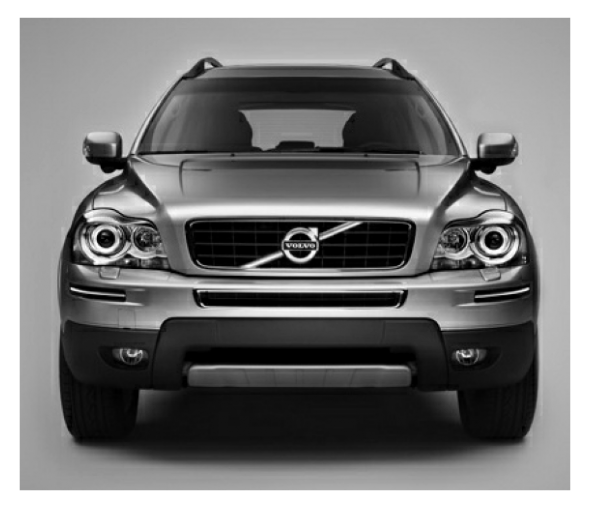

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

image_path = '../images/car.png'
image = tf.io.read_file(image_path)
image = tf.io.decode_png(image, channels=1)  # force grayscale, handles RGB + RGBA

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.show()


## Step 1 — Define the Kernel

Next, we'll define the kernel. The kernel below is an **edge-detection kernel** — it highlights areas where pixel intensity changes sharply (i.e., edges).

You can experiment with different kernel values to see how they change the resulting feature map.


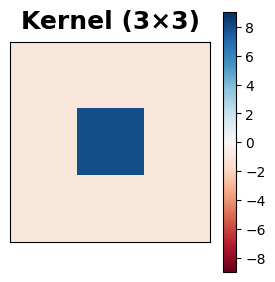

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])

# Visualize kernel using matplotlib (replaces show_kernel)
plt.figure(figsize=(3, 3))
plt.imshow(kernel.numpy(), cmap='RdBu', vmin=-9, vmax=9)
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.title('Kernel (3×3)')
plt.show()


## Step 2 — Apply Convolution

We apply the kernel to the image by computing the **weighted sum** of each 3×3 patch of pixels. This produces the **feature map** — a new image that highlights wherever the kernel pattern is detected.

We use TensorFlow to apply the convolution (just like a `Conv2D` layer does internally).


In [9]:
# ── Step 1: Normalize pixel values from [0, 255] integers → [0.0, 1.0] floats ──
# TensorFlow's conv2d expects float32 input, not uint8.
# convert_image_dtype also scales values automatically (divides by 255).
image = tf.image.convert_image_dtype(image, dtype=tf.float32)

# ── Step 2: Add a batch dimension ──
# Conv2D expects input shape: [batch, height, width, channels]
# Our image is currently [height, width, channels], so we insert a
# size-1 batch dimension at axis=0  →  [1, height, width, channels]
image = tf.expand_dims(image, axis=0)

# ── Step 3: Reshape the kernel to match Conv2D's expected filter shape ──
# tf.nn.conv2d filters must be: [filter_height, filter_width, in_channels, out_channels]
# Our kernel is [3, 3], so *kernel.shape unpacks to (3, 3),
# and we append 1, 1  →  final shape: [3, 3, 1, 1]
# (1 input channel, 1 output feature map)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])

# ── Step 4: Cast kernel to float32 ──
# Both image and kernel must be the same dtype for tf.nn.conv2d to work.
kernel = tf.cast(kernel, dtype=tf.float32)

print('image shape :', image.shape, '  dtype:', image.dtype)
print('kernel shape:', kernel.shape, '  dtype:', kernel.dtype)


image shape : (1, 508, 590, 1)   dtype: <dtype: 'float32'>
kernel shape: (3, 3, 1, 1)   dtype: <dtype: 'float32'>


## Step 3 — Apply ReLU

After convolution, we apply the **ReLU activation** function. ReLU sets all **negative values to zero**, keeping only the positive activations — i.e., the parts of the image where the feature was actually detected.

> 🔑 **Key idea**: Negative values in the feature map mean the kernel pattern was *not* found there. ReLU discards this irrelevant information, leaving only the detected features.


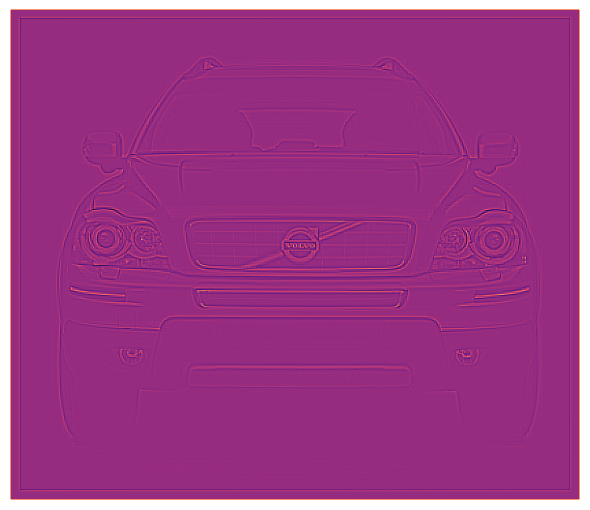

In [10]:
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    # we'll talk about these two in lesson 4!
    strides=1,
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.show()

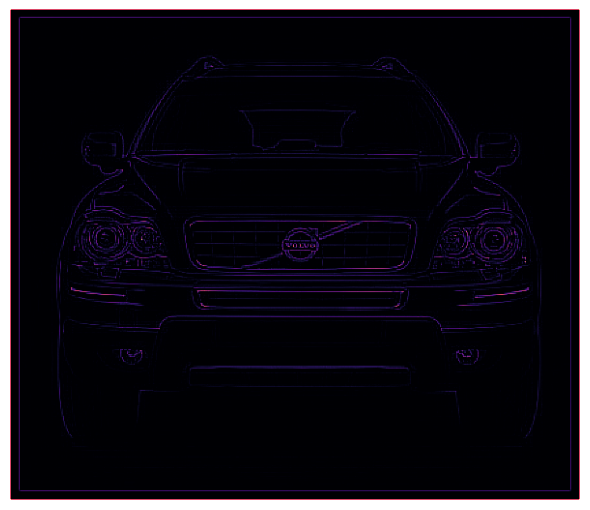

In [ ]:
image_detect = tf.nn.relu(image_filter)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.show()